# NorthStar Urban Mobility — Python Analytics
## Python Data Processing and Analysis

This notebook uses Python (Pandas, NumPy, Matplotlib, Seaborn) to:
- Clean and transform the NorthStar dataset
- Engineer new analytical features not available in the raw data
- Identify root causes of delays, failures, and cost escalation
- Produce visualisations that support the business argument

All findings connect directly to the four operational problems
identified in the case study and extend the SQL/R analysis.


In [1]:
#Uploading Files from the dataset
from google.colab import files
uploaded = files.upload()

Saving app_events.csv to app_events.csv
Saving complaints.csv to complaints.csv
Saving customers.csv to customers.csv
Saving data_dictionary.csv to data_dictionary.csv
Saving deliveries.csv to deliveries.csv
Saving drivers.csv to drivers.csv
Saving hubs.csv to hubs.csv
Saving incidents.csv to incidents.csv
Saving orders.csv to orders.csv
Saving vehicles.csv to vehicles.csv


In [3]:
# Load all nine datasets
customers  = pd.read_csv('/content/customers.csv')
orders     = pd.read_csv('/content/orders.csv')
deliveries = pd.read_csv('/content/deliveries.csv')
drivers    = pd.read_csv('/content/drivers.csv')
hubs       = pd.read_csv('/content/hubs.csv')
vehicles   = pd.read_csv('/content/vehicles.csv')
complaints = pd.read_csv('/content/complaints.csv')
incidents  = pd.read_csv('/content/incidents.csv')
app_events = pd.read_csv('/content/app_events.csv')

print("Datasets loaded:")
for name, df in [('customers',customers), ('orders',orders),
                  ('deliveries',deliveries), ('drivers',drivers),
                  ('hubs',hubs), ('vehicles',vehicles),
                  ('complaints',complaints), ('incidents',incidents),
                  ('app_events',app_events)]:
    print(f"  {name:12s}: {len(df):>5} rows  |  {len(df.columns)} columns")

Datasets loaded:
  customers   :   650 rows  |  9 columns
  orders      :  1250 rows  |  11 columns
  deliveries  :   950 rows  |  13 columns
  drivers     :   170 rows  |  8 columns
  hubs        :     8 rows  |  5 columns
  vehicles    :   120 rows  |  8 columns
  complaints  :   320 rows  |  10 columns
  incidents   :   280 rows  |  7 columns
  app_events  :   640 rows  |  10 columns


## Data Cleaning and Preprocessing

This section focuses on cleaning and preprocessing the loaded datasets to ensure data quality and consistency for subsequent analysis. Key steps include:

*   **Normalizing Inconsistent Zone Names:** Standardizing geographical zone names across different datasets to ensure accurate merging and analysis.
*   **Parsing Datetime Columns:** Converting relevant columns to datetime objects to enable time-series analysis and calculations involving durations.
*   **Handling Missing Values:** Identifying and addressing missing data points through appropriate imputation strategies (e.g., median imputation) or flagging for exclusion in specific analyses.

In [5]:
# CLEANING STEP 1: Normalise inconsistent zone names
zone_map = {
    'north':'North','NORTH':'North',
    'south':'South','SOUTH':'South',
    'east' :'East', 'EAST' :'East',
    'west' :'West', 'WEST' :'West',
    'ctr'  :'Central','CTR':'Central','CENTRAL':'Central','central':'Central',
    'airport':'Airport','AIRPORT':'Airport',
    'riverside':'Riverside','RIVERSIDE':'Riverside','RiverSide':'Riverside',
}

orders['pickup_zone']      = orders['pickup_zone'].str.strip().replace(zone_map)
orders['dropoff_zone']     = orders['dropoff_zone'].str.strip().replace(zone_map)
app_events['zone_context'] = app_events['zone_context'].str.strip().replace(zone_map)
vehicles['assigned_zone']  = vehicles['assigned_zone'].str.strip().replace(zone_map)
customers['home_zone']     = customers['home_zone'].str.strip().replace(zone_map)
drivers['base_zone']       = drivers['base_zone'].str.strip().replace(zone_map)

In [6]:
# CLEANING STEP 2: Parse all datetime columns
deliveries['dispatch_time']         = pd.to_datetime(deliveries['dispatch_time'])
deliveries['delivery_completed_at'] = pd.to_datetime(deliveries['delivery_completed_at'])
orders['order_created_at']          = pd.to_datetime(orders['order_created_at'])
complaints['created_at']            = pd.to_datetime(complaints['created_at'])
incidents['reported_at']            = pd.to_datetime(incidents['reported_at'])
app_events['event_timestamp']       = pd.to_datetime(app_events['event_timestamp'])

In [7]:
# CLEANING STEP 3: Handle missing values
missing_report = {}
for name, df in [('deliveries',deliveries),('orders',orders),('complaints',complaints),
                  ('incidents',incidents),('vehicles',vehicles),('drivers',drivers),
                  ('customers',customers),('app_events',app_events)]:
    m = df.isnull().sum()
    m = m[m > 0]
    if len(m):
        missing_report[name] = m.to_dict()

print("=== MISSING VALUE AUDIT ===")
for ds, fields in missing_report.items():
    for col, count in fields.items():
        print(f"  {ds}.{col}: {count} missing")

# Fill missing compensation with median (not mean — skewed distribution)
complaints['compensation_amount'] = complaints['compensation_amount'].fillna(
    complaints['compensation_amount'].median()
)

# Fill missing training_score with median per employment_type
drivers['training_score'] = drivers.groupby('employment_type')['training_score'].transform(
    lambda x: x.fillna(x.median())
)

# Flag rows where delivery duration cannot be computed (19 missing timestamps)
deliveries['duration_computable'] = deliveries['delivery_completed_at'].notna()
print(f"\nDeliveries with missing completion timestamp: {(~deliveries['duration_computable']).sum()}")
print("These are excluded from delay duration analysis.")

=== MISSING VALUE AUDIT ===
  deliveries.delivery_completed_at: 19 missing
  deliveries.customer_rating_post_delivery: 14 missing
  orders.booking_channel: 25 missing
  complaints.compensation_amount: 16 missing
  incidents.resolved_hours: 17 missing
  vehicles.battery_health_pct: 4 missing
  drivers.training_score: 7 missing
  customers.loyalty_score: 20 missing
  customers.preferred_channel: 13 missing
  app_events.order_id: 144 missing

Deliveries with missing completion timestamp: 19
These are excluded from delay duration analysis.


## Exploratory Data Analysis (EDA)

This section performs initial exploratory data analysis to understand the distributions, identify patterns, and detect anomalies within the cleaned datasets. Visualizations and summary statistics are used to gain preliminary insights into various aspects of NorthStar's operations, complaints, and vehicle health.

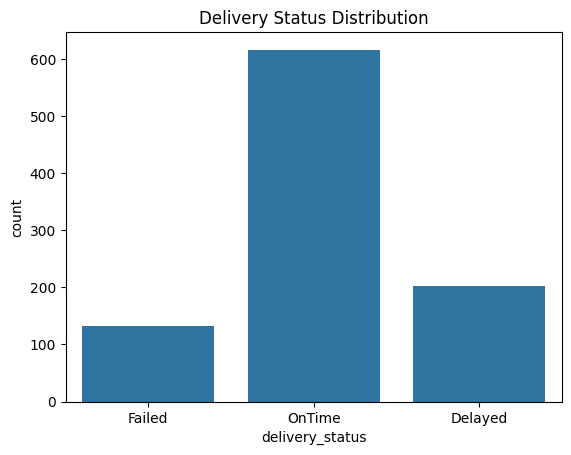

In [8]:
# EDA (Delivery Status Distribution)
sns.countplot(data=deliveries, x='delivery_status')
plt.title("Delivery Status Distribution")
plt.show()

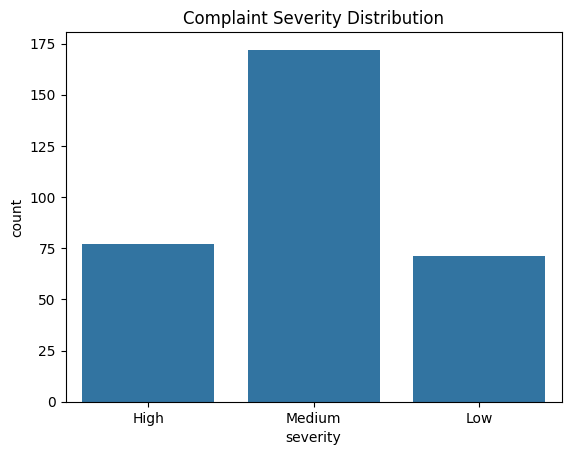

In [ ]:
# EDA (Complaint severity distribution)
sns.countplot(data=complaints, x='severity')
plt.title("Complaint Severity Distribution")
plt.show()

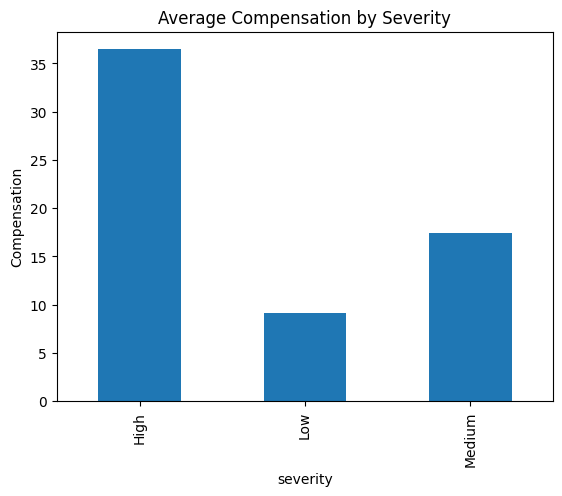

In [15]:
# EDA (Average compensation based on complaints severity)
complaint_cost = (
    complaints
    .groupby('severity')['compensation_amount']
    .mean()
)

complaint_cost.plot(kind='bar')

plt.title('Average Compensation by Severity')
plt.ylabel('Compensation')
plt.show()



## Deep Analysis and Feature Engineering

This section delves deeper into the data by creating a unified master dataset and engineering new features that are crucial for comprehensive analysis. It aims to uncover the root causes of operational challenges, assess profitability risks, and identify areas for strategic intervention. This includes:

*   **Master Dataset Creation:** Merging various datasets into a single comprehensive DataFrame for holistic analysis.
*   **Feature Engineering:** Deriving new metrics such as delivery duration, delay indicators, gross margin, and cost per kilometer to provide more granular insights.
*   **Risk Analysis:** Calculating and visualizing key performance indicators related to failure rates, complaint types, route override behavior, vehicle maintenance risks, and profitability across different operational dimensions.

In [17]:
import pandas as pd
import numpy as np


# MASTER DATASET

master = deliveries.merge(
    orders[['order_id','service_type','pickup_zone','order_value',
            'priority_level','promised_window_hours']],
    on='order_id',
    how='left'
).merge(
    hubs[['hub_id','hub_name','zone']],
    on='hub_id',
    how='left'
).merge(
        drivers[['driver_id',
                 'employment_type']],
        on='driver_id',
)
del_comp = deliveries.merge(orders[['order_id']], on='order_id').merge(
    complaints[['order_id','complaint_id','complaint_type','severity']],
    on='order_id', how='left'
)



# FEATURE ENGINEERING

# Delivery duration (hours)
master['actual_duration_hrs'] = (
    (master['delivery_completed_at'] - master['dispatch_time'])
    .dt.total_seconds() / 3600
)

# Delay vs promised window
master['delay_vs_window'] = master['actual_duration_hrs'] - master['promised_window_hours']

# Late delivery flag
master['is_late'] = master['delay_vs_window'] > 0

# Failure / delay indicators
master['is_failed'] = (master['delivery_status'] == 'Failed')
master['is_delayed'] = (master['delivery_status'] == 'Delayed')

# Financial performance
master['gross_margin'] = master['order_value'] - master['fuel_or_charge_cost']

# Operational efficiency
master['cost_per_km'] = (
    master['fuel_or_charge_cost'] /
    master['route_distance_km'].replace(0, np.nan)
)

print("Master dataset shape:", master.shape)


Master dataset shape: (950, 29)


In [13]:
# Failure Rate by Hub
hub_risk = (
    master.groupby('hub_name')
    .agg(
        total_deliveries=('delivery_id','count'),
        failed=('is_failed','sum')
    )
)

hub_risk['failure_rate'] = (
    hub_risk['failed']
    / hub_risk['total_deliveries']
) * 100

hub_risk = hub_risk.sort_values(
    by='failure_rate',
    ascending=False
)

print(hub_risk)

                total_deliveries  failed  failure_rate
hub_name                                              
Midtown Relay                128      26     20.312500
Central Core                 115      23     20.000000
Airport Hub                  104      15     14.423077
West Gate                    127      16     12.598425
North Exchange               136      17     12.500000
Riverside Hub                115      14     12.173913
South Link                   106      10      9.433962
East Dock                    119      11      9.243697


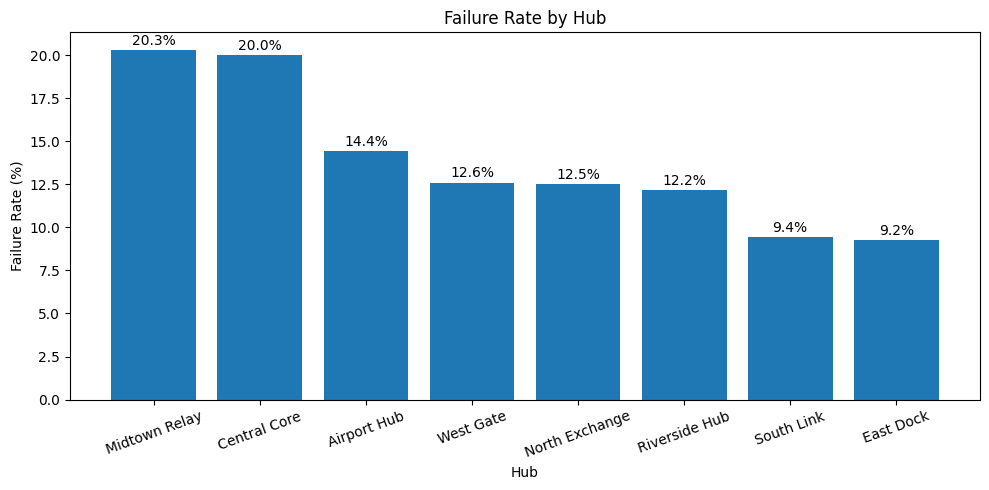

In [14]:
# PYTHON VISUALISATION 1 - Failure Rate by Hub

hub_risk = hub_risk.sort_values(            # Sort highest failure rate first
    by='failure_rate',
    ascending=False
)

plt.figure(figsize=(10,5))
bars = plt.bar(
    hub_risk.index,
    hub_risk['failure_rate']
)
# Add labels
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.3,
        f'{height:.1f}%',
        ha='center'
    )
plt.title('Failure Rate by Hub')
plt.xlabel('Hub')
plt.ylabel('Failure Rate (%)')
plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

In [45]:
# System Mismatch Between Delivery Status and Customer Complaints
mismatch = del_comp.groupby('delivery_status').agg(
    total_deliveries  = ('delivery_id', 'count'), # Renamed for clarity
    total_complaints  = ('complaint_id', lambda x: x.notna().sum())
).assign(
    complaint_rate_pct = lambda x: (x['total_complaints'] /
                                    x['total_deliveries'] * 100).round(1)
).reset_index()

ontime_comp_types = (
    del_comp[
        (del_comp['delivery_status'] == 'OnTime') &
        (del_comp['complaint_id'].notna())
    ]
    .groupby('complaint_type').size().reset_index(name='count')
    .sort_values('count', ascending=True)
)

print(ontime_comp_types.head(10))

      complaint_type  count
1            Billing      7
2             Damage      8
6  SupportExperience     11
0           AppIssue     25
5       MissedPickup     25
4    DriverBehaviour     29
3              Delay     44


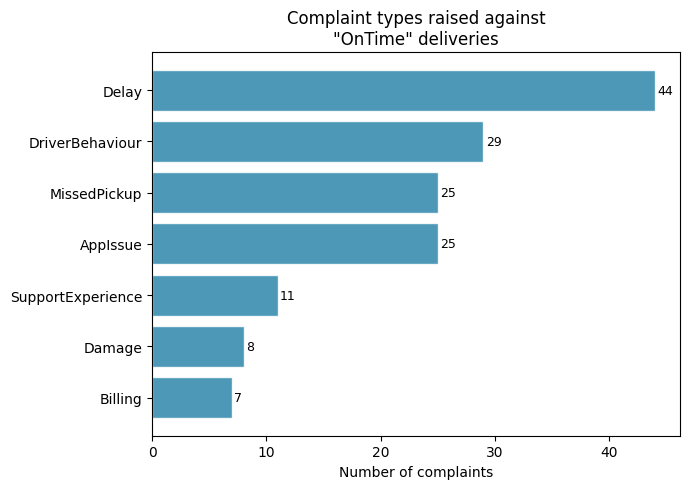

In [50]:
# PYTHON VISUALISATION 2 - System Mismatch Between Delivery Status and Customer Complaints

fig, ax = plt.subplots(1, 1, figsize=(7, 5))

ax.barh(ontime_comp_types['complaint_type'],
          ontime_comp_types['count'],
          color='#2E86AB', edgecolor='white', alpha=0.85)
ax.set(
    xlabel='Number of complaints',
    title='Complaint types raised against\n"OnTime" deliveries'
)
for i, (_, row) in enumerate(ontime_comp_types.iterrows()):
    ax.text(row['count'] + 0.2, i,
             str(int(row['count'])), va='center', fontsize=9)

plt.tight_layout()
plt.show()

In [18]:
#	Route Override Behaviour Analysis
override_analysis = (
    master.groupby('employment_type')
    .agg(
        avg_overrides=('manual_route_override_count','mean'),
        failed_deliveries=('is_failed','sum'),
        total_deliveries=('delivery_id','count')
    )
)
override_analysis['failure_rate'] = (
    override_analysis['failed_deliveries']
    / override_analysis['total_deliveries']
) * 100

print(override_analysis)

                 avg_overrides  failed_deliveries  total_deliveries  \
employment_type                                                       
Contract              0.928571                 18               126   
FullTime              1.024055                 85               582   
PartTime              0.859504                 29               242   

                 failure_rate  
employment_type                
Contract            14.285714  
FullTime            14.604811  
PartTime            11.983471  


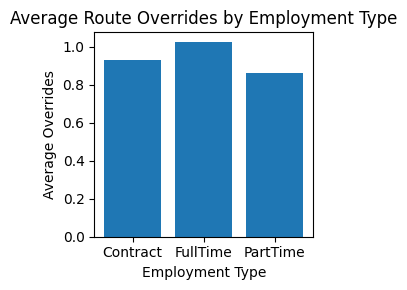

In [19]:
# PYTHON VISUALISATION 3 - Route Override Behaviour Analysis
plt.figure(figsize=(3,3))

plt.bar(
    override_analysis.index,
    override_analysis['avg_overrides']
)
plt.title('Average Route Overrides by Employment Type')
plt.xlabel('Employment Type')
plt.ylabel('Average Overrides')
plt.tight_layout()
plt.show()

In [20]:
# Vehicle Maintenance Risk Analysis
vehicles['battery_band'] = pd.cut(
    vehicles['battery_health_pct'],
    bins=[0,60,75,90,100],
    labels=['Critical','Low','Moderate','Good']
)

battery_summary = (
    vehicles.groupby(['maintenance_status','battery_band'])
    .size()
    .reset_index(name='vehicle_count')
)

print(battery_summary)

   maintenance_status battery_band  vehicle_count
0              Active     Critical              8
1              Active          Low             20
2              Active     Moderate             26
3              Active         Good              9
4            InRepair     Critical              5
5            InRepair          Low              8
6            InRepair     Moderate             16
7            InRepair         Good              7
8           Scheduled     Critical              0
9           Scheduled          Low              8
10          Scheduled     Moderate              7
11          Scheduled         Good              2


/tmp/ipykernel_21383/89466758.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  vehicles.groupby(['maintenance_status','battery_band'])


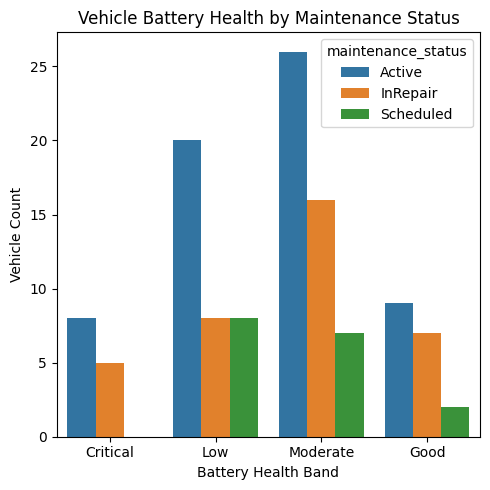

In [21]:
# PYTHON VISUALISATION 4 - Vehicle Maintenance Risk Analysis

plt.figure(figsize=(5,5))

sns.countplot(
    data=vehicles,
    x='battery_band',
    hue='maintenance_status'
)

plt.title('Vehicle Battery Health by Maintenance Status')
plt.xlabel('Battery Health Band')
plt.ylabel('Vehicle Count')

plt.tight_layout()
plt.show()


In [22]:
# Profitability Risk Analysis
profitability = (
    master.groupby(['service_type','pickup_zone'])
    .agg(
        revenue=('order_value','sum'),
        cost=('fuel_or_charge_cost','sum')
    )
    .reset_index()
)
profitability['margin_pct'] = (
    (profitability['revenue']
     - profitability['cost'])
    / profitability['revenue']
) * 100

profit_risk = profitability.sort_values(
    by='margin_pct'
)
print(profit_risk.head(10))



   service_type pickup_zone  revenue    cost  margin_pct
0      Business     Airport  1081.84  244.10   77.436590
10      Medical         Ctr   107.85   22.27   79.350950
32       Retail     Airport  2687.13  519.15   80.680131
7      Business        West   856.36  158.61   81.478584
25    Passenger     Central  2497.80  431.74   82.715189
11      Medical        East  1428.19  245.51   82.809710
12      Medical       North  1300.36  222.47   82.891661
34       Retail         Ctr  1728.18  292.25   83.089146
21       Parcel   Riverside  2007.65  338.88   83.120564
16       Parcel     Airport  3203.73  519.31   83.790457


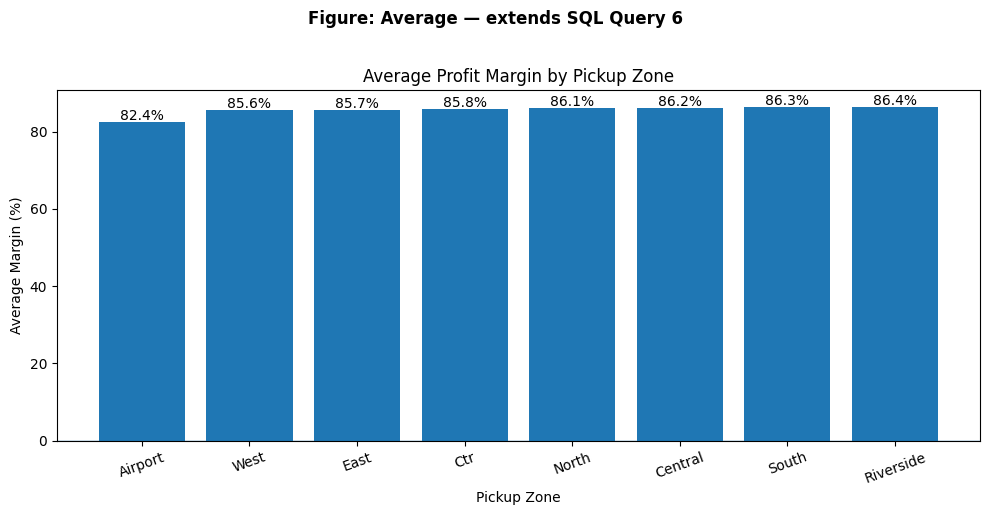

In [48]:
# PYTHON VISUALISATION 4 - Profitability Risk Analysis

zone_margin = (
    profitability.groupby('pickup_zone')['margin_pct']
    .mean()
    .sort_values()
)

plt.figure(figsize=(10,5))
bars = plt.bar(
    zone_margin.index,
    zone_margin.values
)
# Zero line
plt.axhline(0, linewidth=1)
# Add labels
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.5,
        f'{height:.1f}%',
        ha='center'
    )
plt.title('Average Profit Margin by Pickup Zone')
plt.suptitle('Figure: Average — extends SQL Query 6',
             fontweight='bold', y=1.02)
plt.xlabel('Pickup Zone')
plt.ylabel('Average Margin (%)')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

